# Import analytic imagery

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
import rasterio.features

from tqdm import tqdm
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.plot import show
from rasterio.warp import Resampling

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from geopandas import GeoDataFrame

sys.path.append("../utils")

import config

### Import building buffers

In [3]:
buffered_buildings_2022 = os.path.join(
    config.data_dir, "joined_inspections_parcels", "buffered_buildings_2022.geojson"
)

buffered_buildings_2022 = gpd.read_file(buffered_buildings_2022)

### Import imagery

In [4]:
image_path = os.path.join(
    config.data_dir, 
    "imagery_for_test", 
    "wildfire_prep_dataset_test2_psscene_analytic_sr_udm2/PSScene/20200318_164124_1020_3B_AnalyticMS_SR.tif"
)

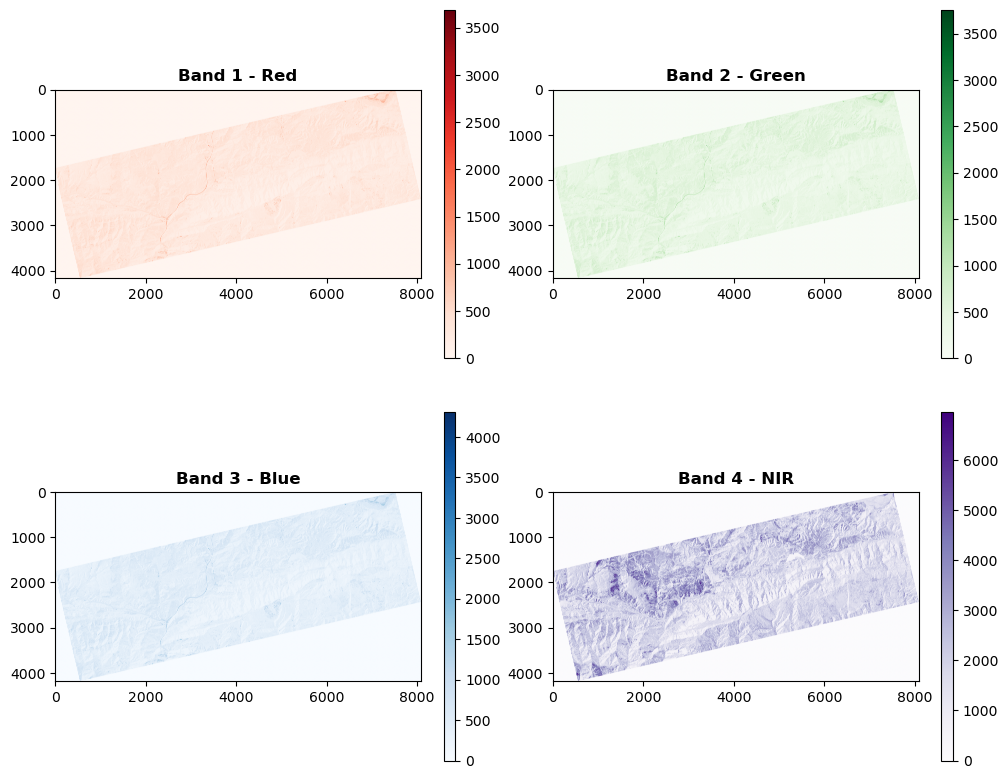

In [5]:
# Open the image file
with rasterio.open(image_path) as src:
    # Read all four bands
    band1 = src.read(1)  # Red
    band2 = src.read(2)  # Green
    band3 = src.read(3)  # Blue
    band4 = src.read(4)  # NIR
    rgb_image = np.stack([band1, band2, band3, band4], axis=-1)

    # you can also read the image as a single array
    # img = src.read([1, 2, 3, 4])

    # Adjust figure size and spacing
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 9))
    plt.subplots_adjust(wspace=0.0, hspace=0.0)  # Adjust spacing between subplots

    im1 = show(band1, ax=ax1, title="Band 1 - Red", cmap="Reds")
    plt.colorbar(im1.get_images()[0], ax=ax1, shrink=0.7, aspect=30)

    im2 = show(band2, ax=ax2, title="Band 2 - Green", cmap="Greens")
    plt.colorbar(im2.get_images()[0], ax=ax2, shrink=0.7, aspect=30)

    im3 = show(band3, ax=ax3, title="Band 3 - Blue", cmap="Blues")
    plt.colorbar(im3.get_images()[0], ax=ax3, shrink=0.7, aspect=30)
    
    im4 = show(band4, ax=ax4, title="Band 4 - NIR", cmap="Purples")
    plt.colorbar(im4.get_images()[0], ax=ax4, shrink=0.7, aspect=30)

    # Adjust layout with specified padding
    plt.tight_layout(pad=0.0)
    plt.show()

In [6]:
def read_and_downscale(image_path, downscale_factor=1):
    with rasterio.open(image_path) as src:
        # Initialize an empty array to hold the downscaled data
        downscaled_data = np.zeros(
            (3, int(src.height / downscale_factor), int(src.width / downscale_factor)),
            dtype=src.meta["dtype"],
        )

        # Iterate over the first 4 bands and downscale each
        for band in range(1, 5):
            data = src.read(
                band,
                out_shape=(
                    1,
                    int(src.height / downscale_factor),
                    int(src.width / downscale_factor),
                ),
                resampling=Resampling.bilinear,
            )
            downscaled_data = data

    return downscaled_data

image = read_and_downscale(image_path, downscale_factor=1)

In [18]:
# Import counties shapefile and filter to Santa Barbara County
counties = gpd.read_file(
    os.path.join(config.data_dir, "ca_counties", "CA_Counties.shp")
)
counties = counties.to_crs(config.geodetic_crs)
sb_county = counties.loc[counties["NAME"] == "Santa Barbara"]

# Create bounding box to remove channel islands
bbox = [-125, 34.25, -119.0, 38.0]
sb_county = sb_county.clip(bbox)

# Convert to Mercator CRS
sb_county = sb_county.to_crs(epsg=4326)

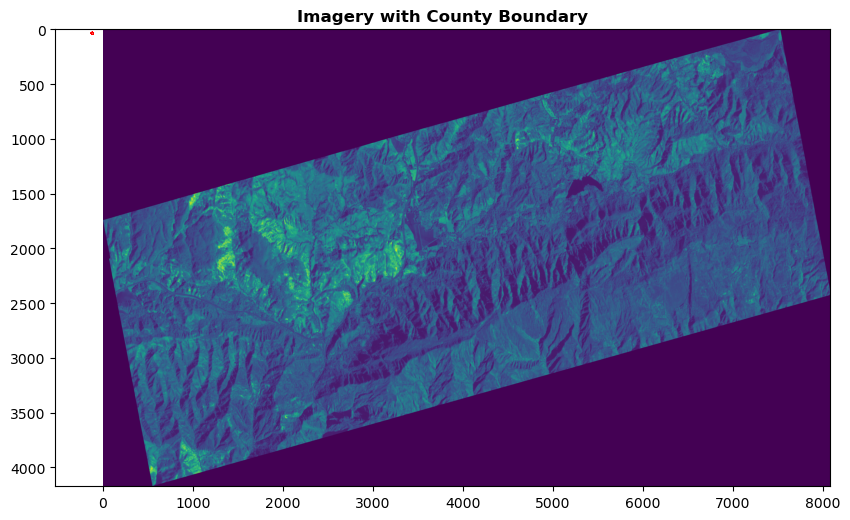

In [19]:
# Plot imagery with county boundary
fig, ax = plt.subplots(figsize=(10, 10))
show(image, ax=ax, title="Imagery with County Boundary")
sb_county.boundary.plot(ax=ax, color="red", linewidth=2)
plt.show()
